In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import sys

print(sys.path)

['/home/nesl/anaconda3/envs/iros24/lib/python312.zip', '/home/nesl/anaconda3/envs/iros24/lib/python3.12', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/lib-dynload', '', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/site-packages']


In [2]:
import glob
import shutil
import random
import numpy as np
import pandas as pd
from os.path import join
from torch.utils.data import Dataset
import torch
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
import configparser
import matplotlib.pyplot as plt
from tqdm import tqdm
import datetime
import json

In [3]:
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
from multimodal import *

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:
### time_window is a changable hyperparam
time_window = 2.0 # a floating number
audio_rate = 16000 # remains fixed
audio_input_length = int(audio_rate * time_window)
n_train_multi_data_per_class = 800
n_test_multi_data_per_class =200

audio_train_set = ESC70Select(
    time_window=time_window,
    folds=[1, 2, 3, 4],
    transforms=lambda x: nn.functional.pad(x,((audio_input_length-x.shape[1])//2, (audio_input_length-x.shape[1])//2))\
        if (x.shape[1] % 2) == 0 \
        else nn.functional.pad(x,((audio_input_length-x.shape[1])//2, (audio_input_length-x.shape[1])//2 + 1)), 
    overwrite=False,
    use_bc_learning=False,
    audio_rate=audio_rate)

imu_train_set = WISDMSelect(
    folds=[1, 2, 3, 4],
    time_window=time_window,
    overwrite=False,
    normalize_acc=True)

audio_train_loader = torch.utils.data.DataLoader(audio_train_set, 
                                            batch_size=32, 
                                            shuffle=True)

imu_train_loader = DataLoader(imu_train_set, batch_size=128, 
                            shuffle=True, num_workers=4)

multimodal_train_set = MultimodalDataset(audio_train_set, 
                                         imu_train_set, 
                                         num_data_per_class=n_train_multi_data_per_class, 
                                         time_window=time_window,
                                         overwrite=False
                                         )

print('Audio data: ({}, {}, {})'.format(len(audio_train_set.sounds), 
                          audio_train_set.sounds[0].shape[0], 
                          audio_train_set.sounds[0].shape[1]))
print('IMU data: ({}, {}, {})'.format(len(imu_train_set.imus), 
                          imu_train_set.imus[0].shape[0], 
                          imu_train_set.imus[0].shape[1]))
print('Audio data: ({}, {}, {})'.format(len(multimodal_train_set.sounds), 
                          multimodal_train_set.sounds[0].shape[0], 
                          multimodal_train_set.sounds[0].shape[1]))
print('IMU data: ({}, {}, {})'.format(len(multimodal_train_set.imus), 
                          multimodal_train_set.imus[0].shape[0], 
                          multimodal_train_set.imus[0].shape[1]))

print(multimodal_train_set.get_label_mapping())

multimodal_train_loader = DataLoader(multimodal_train_set, batch_size=8, 
                            shuffle=True, num_workers=4)
 

./Audio/ESC50/meta/esc50.csv
./Audio/kitchen20/kitchen20.csv
./Audio/silent_sound/silent_sound.csv
Converting sounds to 16000Hz...


./Audio/kitchen20/audio/5-Éplucher un légume.wav-A-17.wav: No such file or directory
./Audio/kitchen20/audio/5-Éplucher un légume.wav-B-17.wav: No such file or directory
./Audio/kitchen20/audio/5-Éplucher un légume.wav-C-17.wav: No such file or directory


Creating corresponding npz file...
Saving
loading  fold1
loading  fold2
loading  fold3
loading  fold4
Creating corresponding npz file...
Saving
loading  fold1
loading  fold2
loading  fold3
loading  fold4
Saving multimodal dataset...
Loading...
Audio data: (954, 1, 32000)
IMU data: (30296, 6, 40)
Audio data: (7200, 1, 32000)
IMU data: (7200, 6, 40)
{'brush_teeth': 0, 'click_mouse': 1, 'drink': 2, 'eat': 3, 'flush_toilet': 4, 'sit': 5, 'type': 6, 'walk': 7, 'wash': 8}


In [6]:
audio_test_set = ESC70Select(
    time_window=time_window,
    folds=[5],
    transforms=lambda x: nn.functional.pad(x,((audio_input_length-x.shape[1])//2, (audio_input_length-x.shape[1])//2))\
        if (x.shape[1] % 2) == 0 \
        else nn.functional.pad(x,((audio_input_length-x.shape[1])//2, (audio_input_length-x.shape[1])//2 + 1)), 
    overwrite=False,
    use_bc_learning=False,
    audio_rate=audio_rate)

audio_test_loader = DataLoader(audio_test_set, batch_size=32, 
                            shuffle=False, num_workers=2)

imu_test_set = WISDMSelect(
    folds=[5],
    time_window=time_window,
    overwrite=False,
    normalize_acc=True)

imu_test_loader = DataLoader(imu_test_set, batch_size=128, 
                            shuffle=False, num_workers=2)


multimodal_test_set = MultimodalDataset(audio_test_set, 
                                        imu_test_set, 
                                        num_data_per_class=n_test_multi_data_per_class,
                                        time_window=time_window,
                                        overwrite=False
                                        )


print('Audio data: ({}, {}, {})'.format(len(multimodal_test_set.sounds), 
                          multimodal_test_set.sounds[0].shape[0], 
                          multimodal_test_set.sounds[0].shape[1]))
print('IMU data: ({}, {}, {})'.format(len(multimodal_test_set.imus), 
                          multimodal_test_set.imus[0].shape[0], 
                          multimodal_test_set.imus[0].shape[1]))

multimodal_test_loader = DataLoader(multimodal_test_set, batch_size=8, 
                            shuffle=True, num_workers=4)

./Audio/ESC50/meta/esc50.csv
./Audio/kitchen20/kitchen20.csv
./Audio/silent_sound/silent_sound.csv
loading  fold5
loading  fold5
Saving multimodal dataset...
Loading...
Audio data: (1800, 1, 32000)
IMU data: (1800, 6, 40)


# Audio Module: BEATs
Use a pre-trained model to extract sound features.

In [7]:
sys.path.append('./saved_models/BEATs')
print(sys.path)

['/home/nesl/anaconda3/envs/iros24/lib/python312.zip', '/home/nesl/anaconda3/envs/iros24/lib/python3.12', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/lib-dynload', '', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/site-packages', './saved_models/BEATs']


In [8]:
audio_train_set.get_label_mapping()

{'no_sound': 0,
 'blender': 1,
 'stove-burner': 2,
 'water-flowing': 3,
 'drawer': 4,
 'clean-dishes': 5,
 'chopping': 6,
 'eat': 7,
 'peel': 8,
 'toilet_flush': 9,
 'footsteps': 10,
 'brushing_teeth': 11,
 'drinking_sipping': 12,
 'mouse_click': 13,
 'keyboard_typing': 14}

In [9]:
from BEATs import BEATs, BEATsConfig

# load the pre-trained checkpoints
checkpoint = torch.load('./saved_models/BEATs/BEATs_iter3_plus_AS2M.pt')

cfg = BEATsConfig(checkpoint['cfg'])
BEATs_model = BEATs(cfg)
BEATs_model.load_state_dict(checkpoint['model'])
BEATs_model.eval()

# extract the the audio representation
audio_input_16khz = audio_train_set.sounds[0]
padding_mask = torch.zeros_like(audio_train_set.sounds[0]).bool()

representation = BEATs_model.extract_features(audio_input_16khz, padding_mask=padding_mask)[0]

/home/nesl/anaconda3/envs/iros24/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [10]:
print(summary(BEATs_model))

Layer (type:depth-idx)                                  Param #
BEATs                                                   --
├─Linear: 1-1                                           393,984
├─Conv2d: 1-2                                           131,072
├─Dropout: 1-3                                          --
├─TransformerEncoder: 1-4                               --
│    └─Sequential: 2-1                                  --
│    │    └─Conv1d: 3-1                                 4,719,488
│    │    └─SamePad: 3-2                                --
│    │    └─GELU: 3-3                                   --
│    └─ModuleList: 2-2                                  --
│    │    └─TransformerSentenceEncoderLayer: 3-4        7,092,244
│    │    └─TransformerSentenceEncoderLayer: 3-5        7,092,244
│    │    └─TransformerSentenceEncoderLayer: 3-6        7,092,244
│    │    └─TransformerSentenceEncoderLayer: 3-7        7,092,244
│    │    └─TransformerSentenceEncoderLayer: 3-8        7,092,244

## Experiment: finetune model on ESC70Select dataset

In [ ]:
class BEATsFinetuned(nn.Module):
    def __init__(self, BEATs_pretrained_model, n_class, predictor_dropout=0.0):
        super().__init__()
        self.BEATs = BEATs_pretrained_model
        self.predictor_dropout = nn.Dropout(predictor_dropout)
        self.predictor = nn.Linear(768, n_class)
 
    def forward(self, x):
        x = self.BEATs.extract_features(x, padding_mask=torch.zeros_like(x).bool())[0]
        x = self.predictor_dropout(x)
        logits = self.predictor(x).mean(dim=1)
        # lprobs = torch.softmax(logits, dim=-1) 
        return logits

    def extract_features(self, x):
        x = self.BEATs.extract_features(x, padding_mask=torch.zeros_like(x).bool())[0]
        x = self.predictor_dropout(x)
        logits = self.predictor(x).mean(dim=1)
        return logits

In [ ]:
# Freeze the pretrained model
for param in BEATs_model.parameters():
    param.requires_grad = False

BEATs_finetuned_model = BEATsFinetuned(BEATs_model, audio_train_set.nClasses)
# output = BEATs_finetuned_model(audio_train_set.sounds[0])
# output.shape

### Training

In [56]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(BEATs_finetuned_model.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.AdamW(BEATs_finetuned_model.parameters(), lr=1e-4, betas=[0.9, 0.95], weight_decay=0.1, )
BEATs_finetuned_model.to(device)

print(audio_train_set.get_label_mapping())
# Training loop
n_epochs = 90
summary = {'loss': [[] for _ in range(n_epochs)], 'acc': [[] for _ in range(n_epochs)]}
for e in range(n_epochs):
    for i, (sounds, labels) in enumerate(audio_train_loader):
        optimizer.zero_grad()
        sounds = sounds.squeeze(dim=1).to(device)
        labels = labels.to(device)
        # Run the Net
        x = BEATs_finetuned_model(sounds)
        # print(x.shape)
        # print(labels.shape)
        # x = x.view(x.size()[:-1])

        # Optimize net
        loss = criterion(x, labels.long())
        loss.backward()
        optimizer.step()
        summary['loss'][e].append(loss.item())

            # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        summary['acc'][e].append(acc.item())
        
    print('Loss: {}, Accuracy: {}'.format(np.mean(summary['loss'][e]), np.mean(summary['acc'][e])))

{'blender': 0, 'no_sound': 1, 'stove-burner': 2, 'water-flowing': 3, 'drawer': 4, 'clean-dishes': 5, 'chopping': 6, 'eat': 7, 'peel': 8, 'toilet_flush': 9, 'footsteps': 10, 'brushing_teeth': 11, 'drinking_sipping': 12, 'mouse_click': 13, 'keyboard_typing': 14}
Loss: 2.7124396165211997, Accuracy: 0.10416666666666667
Loss: 2.6609497388203938, Accuracy: 0.16875
Loss: 2.6116033871968587, Accuracy: 0.25625
Loss: 2.565115706125895, Accuracy: 0.33958333333333335
Loss: 2.5189266045888266, Accuracy: 0.4166666666666667
Loss: 2.474748643239339, Accuracy: 0.46458333333333335
Loss: 2.4310524304707846, Accuracy: 0.525
Loss: 2.387984863917033, Accuracy: 0.5583333333333333
Loss: 2.3452531814575197, Accuracy: 0.6354166666666666
Loss: 2.3034878889719645, Accuracy: 0.6583333333333333
Loss: 2.2621116479237875, Accuracy: 0.6958333333333333
Loss: 2.2213778336842855, Accuracy: 0.71875
Loss: 2.181446822484334, Accuracy: 0.7375
Loss: 2.142564646402995, Accuracy: 0.7604166666666666
Loss: 2.1036294301350913, Acc

### Testing

In [57]:
test_accuracy = []
for i, (sounds, labels) in enumerate(audio_test_loader):
        # Run the Net
        sounds = sounds.squeeze(dim=1).to(device)
        labels = labels.to(device)
        x = BEATs_finetuned_model(sounds)

        # loss = criterion(x, labels.long())
        # summary['loss'][e].append(loss.item())
        # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        summary['acc'][e].append(acc.item())
print(np.mean(summary['acc'][e]))

0.9029605263157895


# IMU Module: LIMU-BERT
A pre-trained autoencoder model using LIMU-BERT architecture to extract acceleration features.

In [11]:
sys.path.append('./saved_models')
sys.path.append('./saved_models/LIMUBert')
print(sys.path)

['/home/nesl/anaconda3/envs/iros24/lib/python312.zip', '/home/nesl/anaconda3/envs/iros24/lib/python3.12', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/lib-dynload', '', '/home/nesl/anaconda3/envs/iros24/lib/python3.12/site-packages', './saved_models/BEATs', './saved_models', './saved_models/LIMUBert']


In [12]:
from LIMUBert.utils import load_model_config, Preprocess4Normalization, IMUDataset
from LIMUBert.models import LIMUBertModel4Pretrain

In [13]:
# Load LIMU-BERT model

model_cfg = load_model_config('pretrain_base', 'base', 'v1', path_bert='./saved_models/LIMUBert/config/limu_bert.json')
if model_cfg is None:
    print("Unable to find corresponding model config!")

pipeline = [Preprocess4Normalization(model_cfg.feature_num)]
LIMUBert_model = LIMUBertModel4Pretrain(model_cfg, output_embed=True)

In [14]:
# load the pre-trained checkpoints
checkpoint = torch.load('./saved_models/LIMUBert/saved/pretrain_base_wisdm_20_100/wisdm.pt')

# cfg = BEATsConfig(checkpoint['cfg'])
# BEATs_model = BEATs(cfg)
LIMUBert_model.load_state_dict(checkpoint)
# LIMUBert_model.eval()
# print(summary(LIMUBert_model))

<All keys matched successfully>

In [15]:
LIMUBert_model.to('cpu')
print(len(imu_test_loader.dataset.imus))
# for i, (imus, labels) in enumerate(imu_test_loader):
#     # Run the Net
# #     print(imus.shape)
#     imus = imus.transpose(-1, 1).to('cpu')
#     labels = labels.to('cpu')
#     x = LIMUBert_model(imus)
#     if i % 50 == 0:
#         print(x.shape)
# print(np.mean(summary['acc'][e]))

# test_output=LIMUBert_model(torch.rand(1, 100, 6))
# test_output.shape

7170


## Experiment: finetune model on WISDMSelect dataset

In [121]:
class LIMUBertFinetuned(nn.Module):
    def __init__(self, LIMUBert_pretrained_model, n_class, predictor_dropout=0.0):
        super().__init__()
        self.LIMUBert = LIMUBert_pretrained_model
        self.predictor_dropout = nn.Dropout(predictor_dropout)
#         self.predictor = nn.Linear(72, n_class)
        self.predictor = GRU(72, n_class)
 
    def forward(self, x):
        x = self.LIMUBert(x.transpose(-1,1)) # Input to LIMUBert model is N * L * C
        x = self.predictor_dropout(x)
#         logits = self.predictor(x).mean(dim=1)
        logits = self.predictor(x)
        # lprobs = torch.sigmoid(logits)
        return logits

    def extract_features(self, x):
        x = self.LIMUBert(x.transpose(-1,1))
        x = self.predictor_dropout(x)
#         logits = self.predictor(x).mean(dim=1)
        logits = self.predictor(x)
        return logits
    
class GRU(nn.Module):
    def __init__(self, input_feature_dim, output_feature_dim, training=False):
        super().__init__()
        self.dropout = True
        self.num_rnn = 2
        self.num_linear = 1
        self.rnn_io = [[input_feature_dim, 20], [20, output_feature_dim]]
        self.num_layers = [2, 1]
        for i in range(self.num_rnn):
            self.__setattr__('gru' + str(i), nn.GRU(self.rnn_io[i][0], self.rnn_io[i][1], num_layers=self.num_layers[i],
                                         batch_first=True))
        

    def forward(self, input_seqs, training=False):
        h = input_seqs
        for i in range(self.num_rnn):
            rnn = self.__getattr__('gru' + str(i))
            h, _ = rnn(h)
            h = nn.functional.relu(h)
#         print(h.shape)  
        h = h[:, -1, :]
#         print(h.shape)
        if self.dropout:
            h = nn.functional.dropout(h, training=training)
        return h

In [124]:
# # Freeze the pretrained model
# for param in LIMUBert_model.parameters():
#     param.requires_grad = False
    
LIMUBert_finetuned_model = LIMUBertFinetuned(LIMUBert_model, imu_train_set.nClasses)
# output = LIMUBert_finetuned_model(imu_train_set.imus[0].unsqueeze(0))
# output.shape
# summary(LIMUBert_finetuned_model)

### Training

In [125]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(LIMUBert_finetuned_model.parameters(), lr=0.001, momentum=0.9)
# optimizer = optim.Adam(params=LIMUBert_finetuned_model.parameters(), lr=1e-3)
# optimizer = torch.optim.AdamW(LIMUBert_finetuned_model.parameters(), lr=1e-3, betas=[0.9, 0.98], weight_decay=0.01, )
optimizer = torch.optim.AdamW(LIMUBert_finetuned_model.parameters(), lr=1e-2, betas=[0.9, 0.98], weight_decay=0.01, )


LIMUBert_finetuned_model.to(device)

imu_train_loader = DataLoader(imu_train_set, batch_size=128, 
                            shuffle=True, num_workers=4)
print(imu_train_set.get_label_mapping())
# Training loop
n_epochs = 100 
summary = {'loss': [[] for _ in range(n_epochs)], 'acc': [[] for _ in range(n_epochs)]}
for e in tqdm(range(n_epochs)):
    for i, (imus, labels) in enumerate(imu_train_loader):
        optimizer.zero_grad()
        imus = imus.to(device)
        labels = labels.to(device)
        # Run the Net
        x = LIMUBert_finetuned_model(imus)
        # print(x.shape)
        # print(labels.shape)
        # x = x.view(x.size()[:-1])

        # Optimize net
        loss = criterion(x, labels.long())
        loss.backward()
        optimizer.step()
        summary['loss'][e].append(loss.item())

            # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        summary['acc'][e].append(acc.item())
        
    print('Loss: {}, Accuracy: {}'.format(np.mean(summary['loss'][e]), np.mean(summary['acc'][e])))

{'walking': 0, 'jogging': 1, 'sitting': 2, 'standing': 3, 'typing': 4, 'teeth': 5, 'pasta': 6, 'drinking': 7}


  1%|          | 1/100 [00:04<07:24,  4.49s/it]

Loss: 1.7828926225251789, Accuracy: 0.41399848269385126


  2%|▏         | 2/100 [00:08<07:12,  4.42s/it]

Loss: 2.032005733578517, Accuracy: 0.1762778618636262


...

Loss: 2.0794413099812052, Accuracy: 0.12224247844158849


  5%|▌         | 5/100 [00:22<07:14,  4.58s/it]

Loss: 2.0794413099812052, Accuracy: 0.122228385086804


  5%|▌         | 5/100 [00:24<07:50,  4.96s/it]


KeyboardInterrupt: 

### Testing

In [86]:
test_summary = {'loss': [], 'acc': []}
for i, (imus, labels) in enumerate(imu_test_loader):
        # Run the Net
        imus = imus.to(device)
        labels = labels.to(device)
        x = LIMUBert_finetuned_model(imus)

        # loss = criterion(x, labels.long())
        # summary['loss'][e].append(loss.item())
        # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        test_summary['acc'].append(acc.item())
print(np.mean(test_summary['acc']))

0.6890901548672567


- optimizer = torch.optim.AdamW(LIMUBert_finetuned_model.parameters(), lr=1e-3, betas=[0.9, 0.98], weight_decay=0.01, ), e = 50 => 0.68
- e=50, lr=1e-2 => 0.64
- e=100, lr=1e-3 => 0.71
- e=200, lr=1e-3,=> 0.70


# Multimodal Model

## Generate Audio and IMU Embeddings

In [16]:
class AudioModule(nn.Module):
    def __init__(self, BEATs_pretrained_model, dropout_p=0.0):
        super().__init__()
        self.BEATs = BEATs_pretrained_model # need to freeze params
        self.dropout = nn.Dropout(dropout_p)
 
    def forward(self, x):
        x = self.BEATs.extract_features(x, padding_mask=torch.zeros_like(x).bool())[0]
        embeddings = self.dropout(x)
#         embeddings = embeddings.mean(dim=1)
        return embeddings


class IMUModule(nn.Module):
    def __init__(self, LIMUBert_pretrained_model, dropout_p=0.0):
        super().__init__()
        self.imu_model = LIMUBert_pretrained_model # need to freeze params
        self.dropout = nn.Dropout(dropout_p)
 
    def forward(self, x):
        x = self.imu_model(x)
        embeddings = self.dropout(x)
        return embeddings
    

class GRU(nn.Module):
    def __init__(self, input_feature_dim, output_feature_dim, training=False):
        super().__init__()
        self.dropout = True
        self.num_rnn = 2
        # self.num_rnn = 1
        self.num_linear = 1
        self.rnn_io = [[input_feature_dim, 256], [256, output_feature_dim]]
        # self.rnn_io = [[input_feature_dim, 128], [128, output_feature_dim]]
        # self.rnn_io = [[input_feature_dim, output_feature_dim]]
        self.num_layers = [2, 1]
        # self.num_layers = [1, 1]
        for i in range(self.num_rnn):
            self.__setattr__('gru' + str(i), nn.GRU(self.rnn_io[i][0], self.rnn_io[i][1], num_layers=self.num_layers[i],
                                         batch_first=True))
            # self.__setattr__('gru' + str(i), nn.GRU(self.rnn_io[i][0], self.rnn_io[i][1], num_layers=self.num_layers[i],
            #                              batch_first=True))
        

    def forward(self, input_seqs, training=False):
        h = input_seqs
        for i in range(self.num_rnn):
            rnn = self.__getattr__('gru' + str(i))
            h, _ = rnn(h)
            h = nn.functional.relu(h)
#         print(h.shape)  
        h = h[:, -1, :]
#         print(h.shape)
        if self.dropout:
            h = nn.functional.dropout(h, training=training)
        return h

In [17]:
def get_multimodal_embed_dataset(multimodal_loader, audio_module, imu_module, device, overwrite=False):
    
    save_path = multimodal_loader.dataset.db_path.split('.npz')[0] + '_embeddings.npz'
    print(save_path)
    time_window = multimodal_loader.dataset.time_window
    config_file = f'./Multimodal/dataset_config_w{time_window}.json'
    
    if not os.path.isfile(save_path) or overwrite:
        dataset = {}
        dataset['audio_embeddings'] = []
        dataset['imu_embeddings'] = []
        dataset['labels'] = []
        
        audio_module.eval()
        imu_module.eval()

        for i, (sounds, imus, labels) in enumerate(multimodal_loader):
            sounds = sounds.squeeze(dim=1).to(device)
            imus = imus.permute(0, 2, 1).to(device)
            
            with torch.no_grad():
                audio_embeddings = audio_module(sounds).cpu().numpy()
                imu_embeddings = imu_module(imus).cpu().numpy()
            
            dataset['audio_embeddings'].append(audio_embeddings)
            dataset['imu_embeddings'].append(imu_embeddings)
            dataset['labels'].append(labels.numpy())
            
        dataset['audio_embeddings'] = np.concatenate(dataset['audio_embeddings'], axis=0)
        dataset['imu_embeddings'] = np.concatenate(dataset['imu_embeddings'], axis=0)
        dataset['labels'] = np.concatenate(dataset['labels'], axis=0)
        
        np.savez(save_path, **dataset)
        
    else:
        dataset = np.load(save_path, allow_pickle=True)
    
    if not os.path.isfile(config_file) or overwrite:
        dataset_config = {}
        dataset_config['db_path'] = save_path
        dataset_config['classes'] = multimodal_loader.dataset.classes
        dataset_config['nClasses'] = multimodal_loader.dataset.nClasses
        dataset_config['time_window'] = multimodal_loader.dataset.time_window
        dataset_config['num_data_per_class'] = multimodal_loader.dataset.num_data_per_class
        dataset_config['label_mapping'] = multimodal_loader.dataset.get_label_mapping()
        
        with open(config_file, 'w') as f:
            json.dump(dataset_config, f)
        
    else:
        with open(config_file, 'r') as f:
            dataset_config = json.load(f)
        
    return dataset, dataset_config

In [18]:
# get Multimodal Embedding Dataset for training and testing
# audio_module = None #AudioModule(BEATs_model).to(device)
# imu_module = None #IMUModule(LIMUBert_model).to(device)
audio_module = AudioModule(BEATs_model).to(device)
imu_module = IMUModule(LIMUBert_model).to(device)

embed_dataset, embed_dataset_config = get_multimodal_embed_dataset(DataLoader(multimodal_train_set, batch_size=32, 
                            shuffle=False, num_workers=4), audio_module, imu_module, device=device, overwrite=False)
multimodal_embed_train_set = MultimodalEmbed(embed_dataset, embed_dataset_config)

embed_dataset, embed_dataset_config = get_multimodal_embed_dataset(DataLoader(multimodal_test_set, batch_size=32, 
                            shuffle=False, num_workers=4), audio_module, imu_module, device=device, overwrite=False)
multimodal_embed_test_set = MultimodalEmbed(embed_dataset, embed_dataset_config)

./Multimodal/MultimodalDataset_audio-32000_1234_imu-40_1234_embeddings.npz


./Multimodal/MultimodalDataset_audio-32000_5_imu-40_5_embeddings.npz


In [19]:
multimodal_embed_train_set.audio_embeddings.shape

(7200, 96, 768)

In [20]:
multimodal_embed_test_set.imu_embeddings.shape

(1800, 40, 72)

In [21]:
# get DataLoader for training and testing
multimodal_embed_train_loader = DataLoader(multimodal_embed_train_set, batch_size=128, 
                            shuffle=True, num_workers=4)
multimodal_embed_test_loader = DataLoader(multimodal_embed_test_set, batch_size=128, 
                            shuffle=False, num_workers=4)

In [22]:
class AudioAndIMUFusion(nn.Module):
    def __init__(
        self,
        audio_feature_dim1,
        imu_feature_dim1,
        audio_feature_dim2,
        imu_feature_dim2,
        fusion_output_dim,
        output_dim,
        dropout_p=0.0,
        ):
        """
        
        """
        super().__init__()
        # self.audio_gru = GRU(audio_feature_dim1, audio_feature_dim2)
        self.audio_fc = nn.Linear(
            in_features=audio_feature_dim1, 
            out_features=audio_feature_dim2
            )

        self.imu_gru = GRU(imu_feature_dim1, imu_feature_dim2)
        # Add minimal batch norm for stability
        self.audio_bn = nn.BatchNorm1d(audio_feature_dim2)
        self.imu_bn = nn.BatchNorm1d(imu_feature_dim2)

        self.fusion = nn.Linear(
            in_features=(audio_feature_dim2 + imu_feature_dim2), 
            out_features=fusion_output_dim
            )
        self.fc = nn.Linear(
            in_features=fusion_output_dim, 
            out_features=output_dim
            )
        self.dropout = nn.Dropout(dropout_p)
    
    def forward(self, audio_embeddings, imu_embeddings):
        # audio_features = self.audio_gru(audio_embeddings)
        audio_features = self.audio_fc(audio_embeddings.mean(dim=1))
#         audio_features = audio_embeddings
#         print(audio_features.shape)
        imu_features = self.imu_gru(imu_embeddings)

        audio_features = self.audio_bn(audio_features)
        imu_features = self.imu_bn(imu_features)

        combined = torch.cat([audio_features, imu_features], dim=1)
        fused = self.dropout(
            nn.functional.relu(
                self.fusion(combined)
                )
            )
        logits = self.fc(fused)
        return logits
    
    def extract_features(self, audio_embeddings, imu_embeddings):
        # audio_features = self.audio_gru(audio_embeddings)
        audio_features = self.audio_fc(audio_embeddings.mean(dim=1))
        imu_features = self.imu_gru(imu_embeddings)

        audio_features = self.audio_bn(audio_features)
        imu_features = self.imu_bn(imu_features)
        
        combined = torch.cat([audio_features, imu_features], dim=1)
        fused = nn.functional.relu(self.fusion(combined))
        
        return fused
        

In [23]:
audio_feature_dim1 = 768
imu_feature_dim1 = 72
audio_feature_dim2 = 128
imu_feature_dim2 = 128
fusion_output_dim = 128
n_class = multimodal_embed_train_set.nClasses

multimodal_model = AudioAndIMUFusion(audio_feature_dim1, 
                                     imu_feature_dim1, 
                                     audio_feature_dim2, 
                                     imu_feature_dim2, 
                                     fusion_output_dim,
                                     n_class,
                                     dropout_p=0.0,
                                    )

## Training

In [24]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(params=multimodal_model.parameters(), lr=0.0001)
# optimizer = torch.optim.AdamW(multimodal_model.parameters(), lr=1e-4, betas=[0.9, 0.999], weight_decay=1e-2, )
optimizer = optim.SGD(multimodal_model.parameters(), lr=0.001, momentum=0.9)
# optimizer = torch.optim.SGD(multimodal_model.parameters(), lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)



# Place on GPU
multimodal_model.to(device)

# Training loop
n_epochs = 20
summary = {'loss': [[] for _ in range(n_epochs)], 'acc': [[] for _ in range(n_epochs)]}
for e in range(n_epochs):
    multimodal_model.train()
    for i, (audio_embeds, imu_embeds, labels) in enumerate((multimodal_embed_train_loader)):
        # Zero the grads
        optimizer.zero_grad()
        audio_embeds = audio_embeds.to(device)
        imu_embeds = imu_embeds.to(device)
        labels = labels.to(device)
        
        # Run the Net
        x = multimodal_model(audio_embeds, imu_embeds)
#         print(x.shape)
        # print(labels.shape)
        # x = x.view(x.size()[:-1])

        # Optimize net
        loss = criterion(x, labels.long())
        loss.backward()
        optimizer.step()
        summary['loss'][e].append(loss.item())

            # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        summary['acc'][e].append(acc.item())

    with torch.no_grad():
        multimodal_model.eval()
        test_loss = []
        test_acc = []
        for i, (audio_embeds, imu_embeds, labels) in enumerate(multimodal_embed_test_loader):
            audio_embeds = audio_embeds.to(device)
            imu_embeds = imu_embeds.to(device)
            labels = labels.to(device)

            # Run the Net
            x = multimodal_model(audio_embeds, imu_embeds)
            # Optimize net
            loss = criterion(x, labels.long())
            test_loss.append(loss.item())

                # Calculat accuracy
            _, pred = x.data.topk(1, dim=1)
            pred = pred.view(pred.shape[:-1])
            acc = torch.sum(pred == labels)/x.shape[0]
            test_acc.append(acc.item())
 
    print('Epoch: {}, Train Loss: {}, Accuracy: {}; Test Loss: {}, Accuracy: {}'.format(e, np.mean(summary['loss'][e]), np.mean(summary['acc'][e]),  np.mean(test_loss), np.mean(test_acc)))

Epoch: 0, Train Loss: 1.7085911725696765, Accuracy: 0.6524122807017544; Test Loss: 1.5607112248738606, Accuracy: 0.7302083333333333
Epoch: 1, Train Loss: 0.9415573655513295, Accuracy: 0.9166666666666666; Test Loss: 0.8516432205835979, Accuracy: 0.8635416666666667
Epoch: 2, Train Loss: 0.5451216990487617, Accuracy: 0.9487390350877193; Test Loss: 0.5971822480360667, Accuracy: 0.8979166666666667
Epoch: 3, Train Loss: 0.3415783633265579, Accuracy: 0.963952850877193; Test Loss: 0.4674606164296468, Accuracy: 0.9145833333333333
Epoch: 4, Train Loss: 0.23808182985113377, Accuracy: 0.9706688596491229; Test Loss: 0.39750751058260597, Accuracy: 0.9177083333333333
Epoch: 5, Train Loss: 0.17577784939816124, Accuracy: 0.9765625; Test Loss: 0.359437291820844, Accuracy: 0.9213541666666667
Epoch: 6, Train Loss: 0.13632620766497494, Accuracy: 0.9812225877192983; Test Loss: 0.3325733145078023, Accuracy: 0.9192708333333334
Epoch: 7, Train Loss: 0.11063671556481144, Accuracy: 0.9847861842105263; Test Loss:

In [25]:
torch.save({
    'model_config': {
        'n_class': n_class,
        'audio_feature_dim1': audio_feature_dim1,
        'imu_feature_dim1': imu_feature_dim1,
        'audio_feature_dim2': audio_feature_dim2,
        'imu_feature_dim2': imu_feature_dim2,
        'fusion_output_dim': fusion_output_dim,
        },
    'model_state_dict': multimodal_model.state_dict(),
    # 'optimizer_state_dict': optimizer.state_dict(),
    }, 
    './saved_models/multimodal_embed_model_w{}_{}-{}.pt'.format(multimodal_embed_train_loader.dataset.time_window, datetime.datetime.now().date().month, datetime.datetime.now().date().day))

## Testing

In [31]:
checkpoint = torch.load('./saved_models/multimodal_embed_model_w2_10-30.pt', map_location=device)

multimodal_model = AudioAndIMUFusion(
                               checkpoint['model_config']['audio_feature_dim1'],
                               checkpoint['model_config']['imu_feature_dim1'],
                               checkpoint['model_config']['audio_feature_dim2'],
                               checkpoint['model_config']['imu_feature_dim2'],
                               checkpoint['model_config']['fusion_output_dim'],
                               checkpoint['model_config']['n_class']
                               )
                                     
multimodal_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

# Generate and save fusion embeddings

In [33]:
multimodal_model.eval()
multimodal_model.to(device)
embeddings1 = 0
for i, (audio_embeds, imu_embeds, labels) in enumerate(multimodal_embed_train_loader):
    audio_embeds = audio_embeds.to(device)
    imu_embeds = imu_embeds.to(device)
    labels = labels.to(device)

    embeddings1 = multimodal_model.extract_features(audio_embeds, imu_embeds).detach().cpu().numpy()
print(embeddings1.shape)

(32, 128)


In [34]:
def get_fusion_embed_dataset(multimodal_embed_loader, multimodal_model, device, overwrite=False):
    
    save_path = multimodal_embed_loader.dataset.db_path.replace('MultimodalDataset', 'fusion')
    print(save_path)
    time_window = multimodal_embed_loader.dataset.time_window
    config_file = f'./Multimodal/dataset_config_w{time_window}.json'
    multimodal_model.eval()
    
    if not os.path.isfile(save_path) or overwrite:
        dataset = {}
        dataset['embeddings'] = []
        dataset['labels'] = []

        for i, (audio_embeds, imu_embeds, labels) in enumerate(multimodal_embed_loader):
            audio_embeds = audio_embeds.to(device)
            imu_embeds = imu_embeds.to(device)

            embeddings = multimodal_model.extract_features(audio_embeds, imu_embeds).detach().cpu().numpy()
            
            dataset['embeddings'].append(embeddings)
            dataset['labels'].append(labels.numpy())
            
        dataset['embeddings'] = np.concatenate(dataset['embeddings'], axis=0)
        dataset['labels'] = np.concatenate(dataset['labels'], axis=0)
        np.savez(save_path, **dataset)
        
    else:
        dataset = np.load(save_path, allow_pickle=True)
    
    with open(config_file, 'r') as f:
        dataset_config = json.load(f)
        
    return dataset, dataset_config


In [ ]:
fusion_dataset, fusion_dataset_config = get_fusion_embed_dataset(multimodal_embed_train_loader, multimodal_model, device, overwrite=False)
fusion_embed_train_set = FusionEmbed(fusion_dataset, fusion_dataset_config)

fusion_dataset, fusion_dataset_config = get_fusion_embed_dataset(multimodal_embed_test_loader, multimodal_model, device, overwrite=False)
fusion_embed_test_set = FusionEmbed(fusion_dataset, fusion_dataset_config)

./Multimodal/fusion_audio-32000_1234_imu-40_1234_embeddings.npz
./Multimodal/fusion_audio-32000_1234_imu-40_1234_embeddings.npz


In [37]:
len(multimodal_embed_test_set)

1800

In [38]:
fusion_embed_train_loader = DataLoader(fusion_embed_train_set, batch_size=128,
                            shuffle=True)
fusion_embed_test_loader = DataLoader(fusion_embed_test_set, batch_size=128,
                            shuffle=False)

In [39]:
class FusionClassifier(nn.Module):
    def __init__(
        self,
        fusion_dim,
        output_dim,
        dropout_p=0.0,
        ):
        super().__init__()
        self.fc = nn.Linear(
            in_features=fusion_dim,
            out_features=output_dim
            )
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, fusion_embeddings):
        logits = self.fc(fusion_embeddings)
        # logits = torch.softmax(logits, dim=1)
        return logits



def train_classifier(fusion_classifier, train_loader, n_epochs=50, optimizer=None, lr=1e-3, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = torch.optim.AdamW(fusion_classifier.parameters(), lr=lr, betas=[0.9, 0.95], weight_decay=0.1, )

    # Place on device
    fusion_classifier.train()
    fusion_classifier.to(device)

    # Training loop
    n_epochs = n_epochs
    summary = {'loss': [[] for _ in range(n_epochs)], 'acc': [[] for _ in range(n_epochs)]}
    for e in range(n_epochs):
        for fusion_embeds, labels in tqdm(train_loader):
            # Zero the grads
            optimizer.zero_grad()
            fusion_embeds = fusion_embeds.to(device)
            labels = labels.to(device)

            # Run the Net
            x = fusion_classifier(fusion_embeds)

            # Optimize net
            loss = criterion(x, labels.long())
            loss.backward()
            optimizer.step()
            summary['loss'][e].append(loss.item())

                # Calculate accuracy
            _, pred = x.data.topk(1, dim=1)
            pred = pred.view(pred.shape[:-1])
            acc = torch.sum(pred == labels)/x.shape[0]
            summary['acc'][e].append(acc.item())

        print('Epoch: {}, Loss: {}, Accuracy: {}'.format(e, np.mean(summary['loss'][e]), np.mean(summary['acc'][e])))


In [40]:
# import sklearn
from sklearn import metrics
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay


@torch.inference_mode
def test_classifier(fusion_classifier, test_loader, class_labels=None, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    fusion_classifier.eval()
    fusion_classifier.to(device)

    test_loss = []
    test_acc = []
    y_pred = []
    y_true = []

    for embeds, labels in tqdm(test_loader):

        # Run the Net
        embeds = embeds.to(device)
        labels = labels.to(device)
        x = fusion_classifier(embeds)
        # Optimize net
        loss = criterion(x, labels.long())
        test_loss.append(loss.item())

            # Calculat accuracy
        _, pred = x.data.topk(1, dim=1)
        pred = pred.view(pred.shape[:-1])
        acc = torch.sum(pred == labels)/x.shape[0]
        test_acc.append(acc.item())
        y_pred.extend(pred)
        y_true.extend(labels)
    
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    cm_display.plot(cmap=plt.cm.Blues, xticks_rotation = 'vertical')


    print('Loss: {}, Accuracy: {}'.format(np.mean(test_loss), np.mean(test_acc)))



In [143]:
fusion_dim = 128
n_class = multimodal_embed_train_set.nClasses

fusion_classifier = FusionClassifier(fusion_dim,
                                    n_class
                                   )

# print(summary(fusion_classifier))

In [149]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# optimizer = torch.optim.AdamW(fusion_classifier.parameters(), lr=1e-4, betas=[0.9, 0.999], weight_decay=1e-4)
# optimizer = torch.optim.AdamW(fusion_classifier.parameters(), lr=1e-4, betas=[0.9, 0.95], weight_decay=0.1, )
# optimizer =torch.optim.Adam(params=fusion_classifier.parameters(), lr=1e-3, weight_decay=0.1)
optimizer = None
train_classifier(fusion_classifier, fusion_embed_train_loader, lr=1e-4, n_epochs=5, optimizer=optimizer, device=device)

  0%|          | 0/57 [00:00<?, ?it/s]

100%|██████████| 57/57 [00:00<00:00, 1210.07it/s]


Epoch: 0, Loss: 0.20895443752146603, Accuracy: 0.9961622807017544


100%|██████████| 57/57 [00:00<00:00, 1882.63it/s]


Epoch: 1, Loss: 0.1656097212904378, Accuracy: 0.9954769736842105


...

Epoch: 2, Loss: 0.13230509480886293, Accuracy: 0.9960252192982456


100%|██████████| 57/57 [00:00<00:00, 1567.55it/s]


Epoch: 3, Loss: 0.10692453802677623, Accuracy: 0.9961622807017544


100%|██████████| 57/57 [00:00<00:00, 1860.15it/s]

Epoch: 4, Loss: 0.08826262804499843, Accuracy: 0.9965734649122807


In [145]:
time_window = fusion_embed_test_set.time_window
config_file = f'./Multimodal/dataset_config_w{time_window}.json'
with open(config_file, 'r') as f:
    dataset_config = json.load(f)
    

In [151]:
fusion_classifier.load_state_dict(torch.load(f'./saved_models/AE_classifier_w{time_window}.pt'))

<All keys matched successfully>

100%|██████████| 15/15 [00:00<00:00, 730.55it/s]

Loss: 0.4617744902769724, Accuracy: 0.9270833333333334


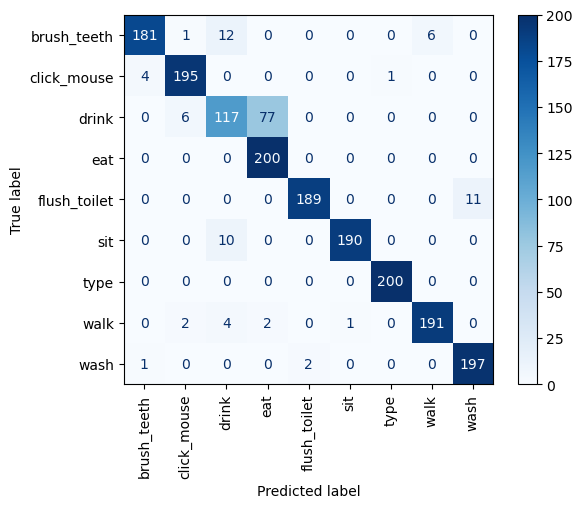

In [152]:
test_classifier(fusion_classifier, fusion_embed_test_loader, class_labels=dataset_config['label_mapping'].keys(),device='cpu')

In [ ]:
# torch.save(fusion_classifier.state_dict(), f'./saved_models/AE_classifier_w{time_window}.pt')

In [35]:
print(len(audio_train_set.sounds))
print(len(imu_train_set.imus))
print(fusion_embed_train_set.embeddings.shape)
print(len(fusion_embed_test_set.label_mapping))


480
12102
(900, 128)
9


In [8]:
from sklearn.model_selection import KFold

In [45]:
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True)

In [37]:
kf.split(multimodal_train_set)[0]

TypeError: 'generator' object is not subscriptable

In [46]:
kf

KFold(n_splits=5, random_state=None, shuffle=True)

In [50]:
print(len(multimodal_train_set))
folds = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(multimodal_train_set)):
    print(f"Fold {fold + 1}", (train_idx, valid_idx))
    folds.append((train_idx, valid_idx))
    


7200
Fold 1 (array([   0,    1,    2, ..., 7197, 7198, 7199]), array([   3,   32,   52, ..., 7190, 7194, 7196]))
Fold 2 (array([   1,    2,    3, ..., 7197, 7198, 7199]), array([   0,    4,    6, ..., 7177, 7181, 7192]))
Fold 3 (array([   0,    2,    3, ..., 7196, 7197, 7199]), array([   1,   16,   18, ..., 7179, 7186, 7198]))
Fold 4 (array([   0,    1,    3, ..., 7195, 7196, 7198]), array([   2,    9,   12, ..., 7193, 7197, 7199]))
Fold 5 (array([   0,    1,    2, ..., 7197, 7198, 7199]), array([   5,   17,   19, ..., 7185, 7187, 7195]))


In [62]:
kf = KFold(n_splits=k_folds, shuffle=True)

folds = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(multimodal_train_set)):
    print(f"Fold {fold + 1}", (train_idx, valid_idx))
    folds.append((train_idx, valid_idx))

for train_idx, valid_idx in folds:
    print(train_idx, valid_idx)
    


Fold 1 (array([   0,    2,    3, ..., 7196, 7198, 7199]), array([   1,    5,   11, ..., 7191, 7195, 7197]))
Fold 2 (array([   0,    1,    3, ..., 7197, 7198, 7199]), array([   2,    4,   18, ..., 7189, 7193, 7194]))
Fold 3 (array([   0,    1,    2, ..., 7197, 7198, 7199]), array([   3,    9,   10, ..., 7164, 7188, 7190]))
Fold 4 (array([   0,    1,    2, ..., 7195, 7197, 7198]), array([   6,    8,   12, ..., 7192, 7196, 7199]))
Fold 5 (array([   1,    2,    3, ..., 7196, 7197, 7199]), array([   0,    7,   21, ..., 7179, 7187, 7198]))
<class 'numpy.ndarray'> [   1    5   11 ... 7191 7195 7197]
<class 'numpy.ndarray'> [   2    4   18 ... 7189 7193 7194]
<class 'numpy.ndarray'> [   3    9   10 ... 7164 7188 7190]
<class 'numpy.ndarray'> [   6    8   12 ... 7192 7196 7199]
<class 'numpy.ndarray'> [   0    7   21 ... 7179 7187 7198]
